# Elastic Net

### Both penalties, and why you would want both

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What mixing L1 and L2 buys, the grouping effect that neither penalty has alone, how to tune two hyperparameters without fooling yourself, and when the extra complexity is not worth it |
| **You should already know** | [Ridge](../04-ridge-regression/) and [Lasso](../05-lasso-regression/) |
| **Dataset** | California Housing, with correlated groups and noise columns planted |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [02-07 Outlier-resistant regression](../07-outlier-resistant-regression/) |

---

## 1. The idea

The two previous notebooks each ended on a limitation.

[Ridge](../04-ridge-regression/) gave coefficients about thirty times steadier
than least squares under resampling, but it never removes a feature. Pushed out
to `alpha=100000` it still had all nine of its columns, the smallest of them at
0.00385 rather than at zero.

[Lasso](../05-lasso-regression/) removes features, and among correlated twins it
kept **one arbitrarily**, with the choice jumping between resamples: across
twelve refits it zeroed 17 of 36 twin coefficients and each of the three twins
took a turn as the largest. Given 30 planted noise columns, `LassoCV` also kept
17 of them, because cross-validation tunes for prediction rather than for a short
list.

Elastic Net adds both penalties and lets you set the mix:

$$J(w) = \|Xw - y\|^2 + \alpha\Big(\rho \sum_i |w_i| + \frac{1-\rho}{2}\sum_i w_i^2\Big)$$

`alpha` sets the total strength, `l1_ratio` ($\rho$) sets the balance. At
$\rho = 1$ it is exactly Lasso; at $\rho = 0$ exactly Ridge.

The interesting behaviour lives strictly in between, and it is not simply "a bit
of each". Adding even a small L2 term produces a **grouping effect**: correlated
features get kept or dropped *together*, with the weight shared between them.
Neither penalty does that alone.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

from sklearn.preprocessing import StandardScaler

X, y = datasets.california_housing()
rng = np.random.default_rng(SEED)

# Three near-copies of the most useful feature, plus 20 pure noise columns.
X_built = X.copy()
for i in range(3):
    X_built[f"MedInc_copy{i}"] = X["MedInc"] + rng.normal(0, 0.02, len(X))
noise = rng.normal(size=(len(X), 20))
names = list(X_built.columns) + [f"noise_{i}" for i in range(20)]
X_full = np.hstack([X_built.values, noise])
TWINS = ["MedInc", "MedInc_copy0", "MedInc_copy1", "MedInc_copy2"]
twin_index = [names.index(c) for c in TWINS]

print(f"{X_full.shape[0]:,} rows, {X_full.shape[1]} columns")
print(f"  {X.shape[1]} real, 3 near-copies of MedInc, 20 pure noise")

20,640 rows, 31 columns
  8 real, 3 near-copies of MedInc, 20 pure noise


## 2. The grouping effect

The direct test. Fit all three penalties and look at what each does to the four
near-identical income columns.

                    MedInc  MedInc_copy0  MedInc_copy1  MedInc_copy2  twins kept  twin sum  noise kept
model                                                                                                 
Ridge (l1_ratio=0)   0.284         0.501        -0.343         0.387           4     0.830          20
Elastic Net (0.5)    0.202         0.209         0.185         0.212           4     0.808           6
Elastic Net (0.9)    0.195         0.288         0.129         0.172           4     0.784           2
Lasso (l1_ratio=1)   0.777         0.001         0.000         0.000           2     0.777           1

correlation of each copy with MedInc: 0.99995, 0.99994, 0.99995
spread between the largest and smallest twin weight:
  Ridge (l1_ratio=0)   0.844   lowest twin -0.343
  Elastic Net (0.5)    0.028   lowest twin +0.185
  Elastic Net (0.9)    0.159   lowest twin +0.129
  Lasso (l1_ratio=1)   0.777   lowest twin +0.000


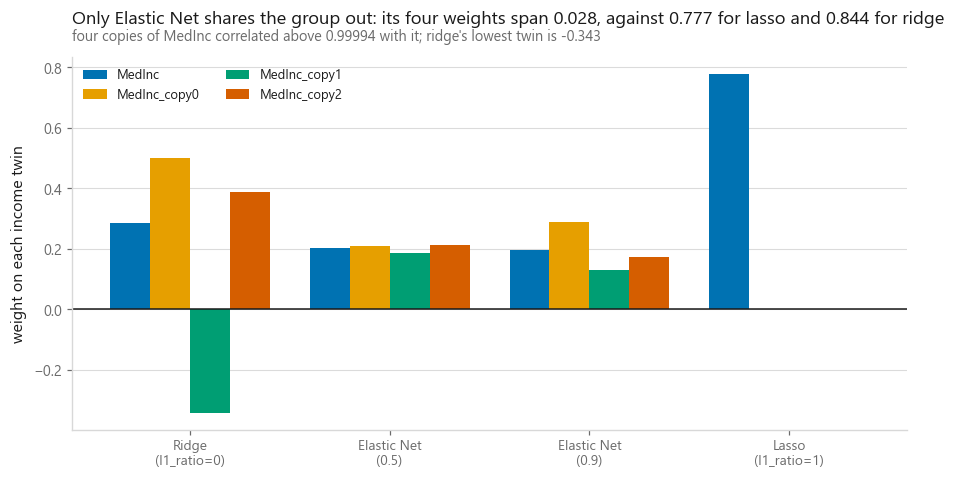

In [2]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

X_scaled = StandardScaler().fit_transform(X_full)

fits = {
    "Ridge (l1_ratio=0)": Ridge(alpha=1.0),
    "Elastic Net (0.5)": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=50000),
    "Elastic Net (0.9)": ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=50000),
    "Lasso (l1_ratio=1)": Lasso(alpha=0.01, max_iter=50000),
}

rows = []
for label, model in fits.items():
    coefficients = model.fit(X_scaled, y).coef_
    twin_weights = coefficients[twin_index]
    rows.append({
        "model": label,
        **{c: w for c, w in zip(TWINS, twin_weights)},
        "twins kept": int((np.abs(twin_weights) > 1e-8).sum()),
        "twin sum": twin_weights.sum(),
        "noise kept": int((np.abs(coefficients[len(X_built.columns):]) > 1e-8).sum()),
    })
grouping = pd.DataFrame(rows).set_index("model")

# Grouped bars, not stacked. A stacked bar draws a negative segment downward over
# the top of the segment below it, which hides both of them, and one of these four
# rows has a negative weight that is the whole point of the row.
fig, ax = plt.subplots(figsize=(9.8, 4.4))
positions = np.arange(len(grouping))
width = 0.2
for i, twin in enumerate(TWINS):
    ax.bar(positions + (i - (len(TWINS) - 1) / 2) * width, grouping[twin],
           width=width, color=style.PALETTE[i], label=twin)
ax.axhline(0, color=style.INK, lw=1)
ax.set_xticks(positions, [m.replace(" (", "\n(") for m in grouping.index], fontsize=9)
ax.set_ylabel("weight on each income twin")
ax.legend(fontsize=8.5, ncols=2)

spans = {label: grouping.loc[label, TWINS].max() - grouping.loc[label, TWINS].min()
         for label in grouping.index}
lowest = grouping[TWINS].min(axis=1)
correlations = [X_built["MedInc"].corr(X_built[c]) for c in TWINS[1:]]

style.title(
    ax,
    f"Only Elastic Net shares the group out: its four weights span "
    f"{spans['Elastic Net (0.5)']:.3f}, against {spans['Lasso (l1_ratio=1)']:.3f} "
    f"for lasso and {spans['Ridge (l1_ratio=0)']:.3f} for ridge",
    f"four copies of MedInc correlated above {min(correlations):.5f} with it; "
    f"ridge's lowest twin is {lowest['Ridge (l1_ratio=0)']:+.3f}",
)
style.save(fig, FIG / "fig-01-grouping.png")

print(grouping.round(3).to_string())
print(f"\ncorrelation of each copy with MedInc: "
      + ", ".join(f"{c:.5f}" for c in correlations))
print("spread between the largest and smallest twin weight:")
for label, span in spans.items():
    print(f"  {label:<20} {span:.3f}   lowest twin {lowest[label]:+.3f}")

Read the individual twin columns rather than just the count. Lasso concentrates
almost the entire income weight on a single twin, 0.777 of a total of 0.777, and
leaves the others at or near zero. Elastic Net at 0.5 spreads 0.808 across four
weights that all sit between 0.185 and 0.212, a span of 0.028. That is the
grouping effect, and neither parent penalty produces it.

**Ridge keeps all four and makes a mess of them**, which is the row I nearly
missed because I drew this chart as a stacked bar first. Its weights are 0.284,
0.501, -0.343 and 0.387: a span of 0.844, wider than lasso's, and one of the four
copies of a positive predictor is handed a *negative* weight so the others can be
larger. A stacked bar drew that -0.343 downward on top of the 0.501 segment, so
the rendered chart showed no negative anywhere and left about a third of copy0's
bar visible, so it read as a small positive rather than as 0.501.
Grouped bars and a zero line, and the row says what it always said.

That looks like a contradiction of the [ridge chapter](../04-ridge-regression/),
where two twins converged to an even split. It is not. It is a statement about
`alpha=1` rather than about ridge, and the cell below separates the two.

In [3]:
# Ridge's row above is drawn at alpha=1. Raise it and watch the same four twins.
print(f"{'alpha':>8}  " + "  ".join(f"{c:>13}" for c in TWINS) + f"  {'span':>7}  {'sum':>7}")
for a in [1, 10, 100, 1000, 10000]:
    twin_weights = Ridge(alpha=a).fit(X_scaled, y).coef_[twin_index]
    print(f"{a:>8}  " + "  ".join(f"{v:>+13.3f}" for v in twin_weights)
          + f"  {twin_weights.max() - twin_weights.min():>7.3f}  {twin_weights.sum():>7.3f}")

   alpha         MedInc   MedInc_copy0   MedInc_copy1   MedInc_copy2     span      sum
       1         +0.284         +0.501         -0.343         +0.387    0.844    0.830
      10         +0.220         +0.289         +0.063         +0.259    0.227    0.830
     100         +0.210         +0.219         +0.190         +0.215    0.028    0.834
    1000         +0.208         +0.210         +0.206         +0.209    0.004    0.833
   10000         +0.181         +0.181         +0.181         +0.181    0.000    0.723


The L2 penalty charges for the *length* of the weight vector, and among
interchangeable columns the cheapest way to deliver a given total is to divide it
evenly, because four weights of 0.2 cost a quarter of what one weight of 0.8
costs. So ridge does group. It has to be paying attention first, and at
`alpha=1` on 20,640 rows it is not: the penalty is a rounding error next to the
data term, and the chart is showing least squares picking an arbitrary point on
an almost perfectly flat ridge. The span across the four twins falls from 0.844
at alpha 1 to 0.227 at 10, 0.028 at 100 and 0.004 at 1000, while the sum holds
near 0.83 until the penalty finally starts shrinking the group as a whole.

So the top row of that chart is not measuring L2 against L1. **It is measuring a
weak penalty against a strong one**, and the rows are labelled by penalty while
differing in strength, which is the exact thing to watch for in anyone's
coefficient plot. What Elastic Net genuinely has over ridge here is that it
reaches the grouped solution at an alpha two orders of magnitude smaller, and
zeroes noise on the way, which ridge never does at any alpha.

Ridge also keeps every one of the 20 noise columns. Elastic Net is the only row
that holds the correlated group together **and** throws most of the noise away.

The `twin sum` column is the check that they are all solving the same problem:
the total weight given to income runs 0.777 to 0.830 across every row. They
differ only in how it is distributed.

### And is the choice stable?

lasso       : mean spread across 12 refits = 0.2938
elastic net : mean spread across 12 refits = 0.0190


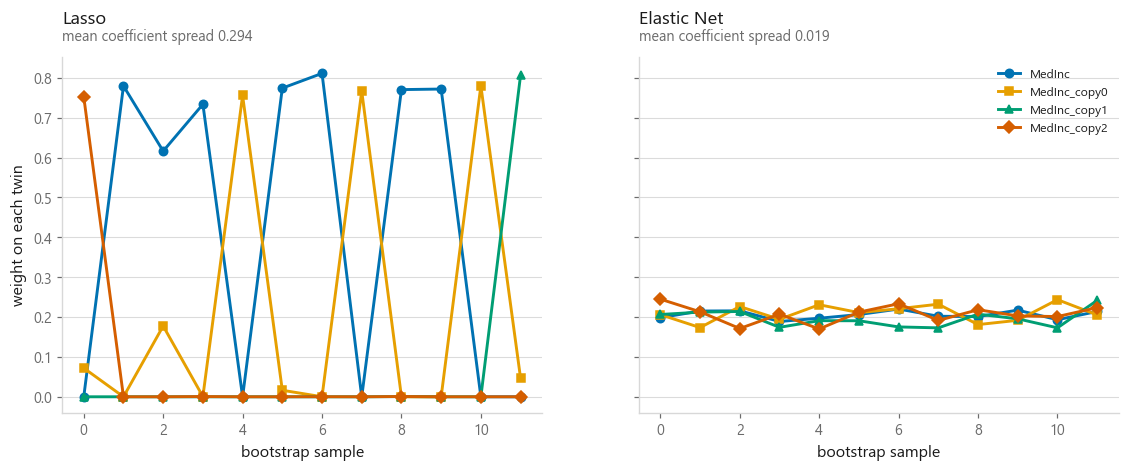

In [4]:
records = []
for trial in range(12):
    sample = rng.choice(len(X_scaled), 4000, replace=True)
    for label, model in [("lasso", Lasso(alpha=0.01, max_iter=50000)),
                         ("elastic net", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=50000))]:
        coefficients = model.fit(X_scaled[sample], y.values[sample]).coef_
        records.append({"trial": trial, "model": label,
                        **{c: coefficients[i] for c, i in zip(TWINS, twin_index)}})
stability = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2), sharey=True)
for ax, label in zip(axes, ["lasso", "elastic net"]):
    subset = stability[stability.model == label]
    for i, twin in enumerate(TWINS):
        ax.plot(subset["trial"], subset[twin], marker=style.MARKERS[i],
                color=style.PALETTE[i], label=twin)
    spread = np.mean([subset[t].std() for t in TWINS])
    ax.set_xlabel("bootstrap sample")
    style.title(ax, label.title(), f"mean coefficient spread {spread:.3f}")
axes[0].set_ylabel("weight on each twin")
axes[1].legend(fontsize=8)
style.save(fig, FIG / "fig-02-stability.png")

for label in ["lasso", "elastic net"]:
    subset = stability[stability.model == label]
    print(f"{label:<12}: mean spread across 12 refits = "
          f"{np.mean([subset[t].std() for t in TWINS]):.4f}")

## 3. Tuning two dials at once

Two hyperparameters means a grid, and it means being careful. `ElasticNetCV`
searches `l1_ratio` and `alpha` together using cross-validation, and the search
has to sit **inside** the outer evaluation or the score is optimistic.

best RMSE on the grid : 0.7265
  at alpha=0.00316, l1_ratio=0.9
worst RMSE on the grid: 1.1539

holding alpha at its best value, moving l1_ratio across all 6 settings changes RMSE by 0.0003
holding l1_ratio at its best value, moving alpha across all 25 settings changes RMSE by 0.4274


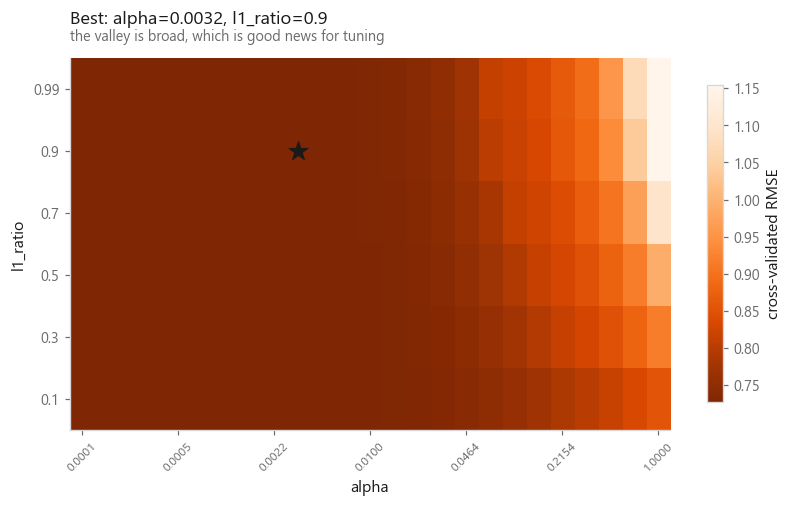

In [5]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

folds = KFold(5, shuffle=True, random_state=SEED)
ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
alphas = np.logspace(-4, 0, 25)

surface = np.zeros((len(ratios), len(alphas)))
for i, ratio in enumerate(ratios):
    for j, alpha in enumerate(alphas):
        model = make_pipeline(StandardScaler(),
                              ElasticNet(alpha=alpha, l1_ratio=ratio, max_iter=20000))
        surface[i, j] = -cross_val_score(model, X_full, y, cv=folds,
                                         scoring="neg_root_mean_squared_error",
                                         n_jobs=-1).mean()

fig, ax = plt.subplots(figsize=(8.8, 4.4))
image = ax.imshow(surface, aspect="auto", cmap="Oranges_r", origin="lower")
best_i, best_j = np.unravel_index(np.argmin(surface), surface.shape)
ax.scatter([best_j], [best_i], s=170, marker="*", c=style.INK, zorder=5)
ax.set_xticks(range(0, len(alphas), 4), [f"{a:.4f}" for a in alphas[::4]], rotation=45, fontsize=8)
ax.set_yticks(range(len(ratios)), [str(r) for r in ratios])
ax.set_xlabel("alpha")
ax.set_ylabel("l1_ratio")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.85, label="cross-validated RMSE")
style.title(ax, f"Best: alpha={alphas[best_j]:.4f}, l1_ratio={ratios[best_i]}",
            "the valley is broad, which is good news for tuning")
style.save(fig, FIG / "fig-03-tuning.png")

print(f"best RMSE on the grid : {surface.min():.4f}")
print(f"  at alpha={alphas[best_j]:.5f}, l1_ratio={ratios[best_i]}")
print(f"worst RMSE on the grid: {surface.max():.4f}")
print(f"\nholding alpha at its best value, moving l1_ratio across all "
      f"{len(ratios)} settings changes RMSE by "
      f"{surface[:, best_j].max() - surface[:, best_j].min():.4f}")
print(f"holding l1_ratio at its best value, moving alpha across all "
      f"{len(alphas)} settings changes RMSE by "
      f"{surface[best_i, :].max() - surface[best_i, :].min():.4f}")

The valley is broad and flat, and the two printed spans say how lopsidedly. Slide
`l1_ratio` across its whole range with `alpha` held at the winner and the score
barely notices; slide `alpha` across its whole range with `l1_ratio` held and it
moves by a large fraction of the error itself. **The two dials are not equally
important, and almost all of the work is `alpha`.** Tune `alpha` carefully and
`l1_ratio` casually, and note that this is also why cross-validation will pick
the `l1_ratio` almost at random from the flat part, which section 4 pays for.

## 4. Is any of it worth it?

The honest comparison, on the constructed dataset with correlated twins and
planted noise, which is the situation Elastic Net was designed for.

                          RMSE  noise kept  twins kept
model                                                 
ordinary least squares  0.7268          20           4
ridge (CV)              0.7269          20           4
lasso (CV)              0.7269          10           2
elastic net (CV)        0.7268          10           2

RMSE span across all four: 0.0001
ElasticNetCV and LassoCV kept the same number of noise columns: True
ElasticNetCV kept 2 of 4 twins, against 4 for the hand-set l1_ratio=0.5 above


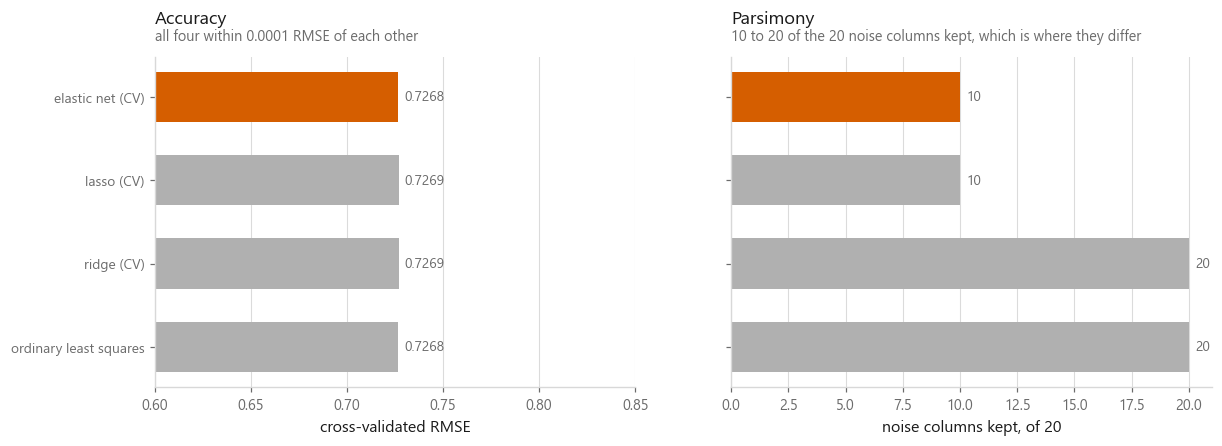

In [6]:
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV

contenders = {
    "ordinary least squares": LinearRegression(),
    "ridge (CV)": RidgeCV(alphas=np.logspace(-3, 3, 30)),
    "lasso (CV)": LassoCV(cv=5, max_iter=50000, random_state=SEED),
    "elastic net (CV)": ElasticNetCV(l1_ratio=ratios, cv=5, max_iter=50000,
                                     random_state=SEED, n_jobs=-1),
}

results = []
for label, model in contenders.items():
    pipeline = make_pipeline(StandardScaler(), model)
    score = -cross_val_score(pipeline, X_full, y, cv=folds,
                             scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    fitted = pipeline.fit(X_full, y)
    coefficients = fitted[-1].coef_
    results.append({
        "model": label,
        "RMSE": score,
        "noise kept": int((np.abs(coefficients[len(X_built.columns):]) > 1e-8).sum()),
        "twins kept": int((np.abs(coefficients[twin_index]) > 1e-8).sum()),
    })
comparison = pd.DataFrame(results).set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.9))
positions = np.arange(len(comparison))
axes[0].barh(positions, comparison["RMSE"], color=style.NEUTRAL, height=0.6)
axes[0].barh([positions[-1]], [comparison["RMSE"].iloc[-1]], color=style.HIGHLIGHT, height=0.6)
for i, v in enumerate(comparison["RMSE"]):
    axes[0].text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=9, color=style.MUTED)
axes[0].set_yticks(positions, comparison.index, fontsize=9)
axes[0].set_xlim(0.6, 0.85)
axes[0].set_xlabel("cross-validated RMSE")
axes[0].grid(axis="y", visible=False); axes[0].grid(axis="x", visible=True)
style.title(axes[0], "Accuracy",
            f"all four within {comparison['RMSE'].max() - comparison['RMSE'].min():.4f} "
            f"RMSE of each other")

axes[1].barh(positions, comparison["noise kept"], color=style.NEUTRAL, height=0.6)
axes[1].barh([positions[-1]], [comparison["noise kept"].iloc[-1]], color=style.HIGHLIGHT, height=0.6)
for i, v in enumerate(comparison["noise kept"]):
    axes[1].text(v + 0.3, i, f"{v}", va="center", fontsize=9, color=style.MUTED)
axes[1].set_yticks(positions, ["" for _ in positions])
axes[1].set_xlabel("noise columns kept, of 20")
axes[1].grid(axis="y", visible=False); axes[1].grid(axis="x", visible=True)
style.title(axes[1], "Parsimony",
            f"{comparison['noise kept'].min()} to {comparison['noise kept'].max()} "
            f"of the 20 noise columns kept, which is where they differ")

style.save(fig, FIG / "fig-04-comparison.png")

print(comparison.round(4).to_string())
print(f"\nRMSE span across all four: "
      f"{comparison['RMSE'].max() - comparison['RMSE'].min():.4f}")
print(f"ElasticNetCV and LassoCV kept the same number of noise columns: "
      f"{comparison.loc['elastic net (CV)', 'noise kept'] == comparison.loc['lasso (CV)', 'noise kept']}")
print(f"ElasticNetCV kept {comparison.loc['elastic net (CV)', 'twins kept']} of "
      f"{len(TWINS)} twins, against {len(TWINS)} for the hand-set l1_ratio=0.5 above")

All four land within 0.0001 RMSE of each other. If prediction error is the only
thing you look at, you would never know which one you ran, and every argument in
this notebook lives in the coefficients instead.

**And the coefficients say `ElasticNetCV` did not do the thing the chapter is
about.** It kept 10 noise columns and 2 twins, which is exactly what `LassoCV`
kept, and nothing like the four-way even split that `l1_ratio=0.5` produced in
section 2.

That is not a bug, it is the same trap as [`LassoCV` not being a feature
selector](../05-lasso-regression/), arriving one notebook later by a different
route. Cross-validation searched for the pair minimising prediction error, the
`l1_ratio` axis is nearly flat so it has almost nothing to go on there, and the
flat part it wandered into is the L1-heavy end. At `l1_ratio=0.9` with a small
alpha, Elastic Net *is* Lasso for practical purposes, and **the grouping effect
and the stability that comes with it are gone**, which is the entire reason you
reached for Elastic Net.

So: if you want the grouping effect, ask for it. Set a lower `l1_ratio` yourself
or restrict the search range, and accept the RMSE that costs, which on this data
is fractions of a thousandth. Letting cross-validation choose freely hands the
behaviour back to Lasso while the score stays flat enough that nothing warns you.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You have correlated groups of features **and** want selection. That combination is the entire reason it exists |
| **Prefer Lasso when** | Features are largely independent and you want the simplest possible model |
| **Prefer Ridge when** | You want stability and have no interest in removing features |
| **Scaling needed** | Yes, as for both parents |
| **Main dials** | `alpha` for strength, `l1_ratio` for the mix. Sweeping `alpha` spanned 0.4274 RMSE here; sweeping `l1_ratio` spanned 0.0003 |
| **Tuning** | `ElasticNetCV` searches both. Keep it inside the outer cross-validation |
| **Watch out** | It optimises prediction, so it drifted to `l1_ratio=0.9` and selected exactly like Lasso. Constrain the range if grouping is the goal |
| **Watch out more** | Two hyperparameters is twice the chance of tuning on the test set. It also converges slowly. Expect to raise `max_iter` |

## What to remember

1. Elastic Net is $\rho$ parts Lasso and $1-\rho$ parts Ridge.
2. The grouping effect is the real reason to use it: correlated features are kept
   or dropped together, with the weight shared.
3. That makes the selected feature set far more stable than Lasso's across resamples.
4. The tuning surface is broad, so `alpha` does most of the work and `l1_ratio`
   tolerates being approximately right.
5. On accuracy alone all three regularisers tie, within 0.0001 RMSE here. The
   difference is which features survive, and how reliably.
6. `ElasticNetCV` optimises prediction, and because the `l1_ratio` axis is nearly
   flat it drifted to `l1_ratio=0.9` and selected exactly what `LassoCV`
   selected. At that setting the grouping effect is gone. If grouping is why you
   are here, set `l1_ratio` yourself or bound the search.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-07 Outlier-resistant regression](../07-outlier-resistant-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#ElasticNet` `#Regularization` `#L1` `#L2` `#FeatureSelection`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#Regression`